# SurvivalNet Demo

This notebook demonstrates an end-to-end workflow using the TCGA expression matrix and the paired clinical survival table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from survivalnet import CoxModel, fit_km, plot_grouped_km_with_pvalue, split_risk_group
from survivalnet.models import LassoCoxModel

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

EXPR_FILENAME = "TCGA.LUAD.sampleMap.txt"
CLINICAL_FILENAME = "LUAD_survival.txt"
EXAMPLE_DIR = Path("examples")


def find_existing_file(*relative_paths: Path) -> Path:
    """Return the first existing path from a list of candidates."""
    for candidate in relative_paths:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find any of: {', '.join(str(path) for path in relative_paths)}"
    )


expr_path = find_existing_file(
    EXAMPLE_DIR / EXPR_FILENAME,
    Path(EXPR_FILENAME),
    Path("../examples") / EXPR_FILENAME,
)
clinical_path = find_existing_file(
    EXAMPLE_DIR / CLINICAL_FILENAME,
    Path(CLINICAL_FILENAME),
    Path("../examples") / CLINICAL_FILENAME,
)

print(f"Using expression file: {expr_path.resolve()}")
print(f"Using clinical file: {clinical_path.resolve()}")

Using expression file: /home/vincent/Desktop/SurvivalNet/examples/TCGA.LUAD.sampleMap.txt
Using clinical file: /home/vincent/Desktop/SurvivalNet/examples/LUAD_survival.txt


In [2]:
def load_expression_matrix(path: Path) -> pd.DataFrame:
    """Load TCGA expression matrix and convert it to sample-by-gene layout."""
    expr = pd.read_csv(path, sep="\t", index_col=0).T.reset_index(names="PATIENT_ID")
    return expr


def load_clinical_table(path: Path) -> pd.DataFrame:
    """Load LUAD survival data and normalize the key columns."""
    clinical = pd.read_csv(path, sep="\t").rename(
        columns={"sample": "PATIENT_ID", "OS.time": "duration", "OS": "event"}
    )
    clinical = clinical[["PATIENT_ID", "duration", "event"]].dropna().copy()
    clinical["duration"] = (
    pd.to_numeric(
        clinical["duration"],
        errors="coerce",
    )
    / 30.44
).round(2)
    clinical["event"] = pd.to_numeric(clinical["event"], errors="coerce")
    clinical = clinical.dropna(subset=["event"])
    clinical["event"] = clinical["event"].astype(int)
    return clinical


expr_df = load_expression_matrix(expr_path)
clinical_df = load_clinical_table(clinical_path)
data = clinical_df.merge(expr_df, on="PATIENT_ID", how="inner")

print("Data loaded successfully")
print(f"Expression matrix: {expr_df.shape}")
print(f"Clinical table: {clinical_df.shape}")
print(f"Merged analysis set: {data.shape}")

Data loaded successfully
Expression matrix: (576, 20531)
Clinical table: (632, 3)
Merged analysis set: (567, 20533)


In [3]:
# Quick sanity check
display(data[["PATIENT_ID", "duration", "event"]].head())
print(f"Merged rows: {len(data)}")
print(f"Merged columns: {len(data.columns)}")

,PATIENT_ID,duration,event
0,TCGA-05-4244-01,0.00,0
1,TCGA-05-4249-01,50.03,0
2,TCGA-05-4250-01,3.98,1
3,TCGA-05-4382-01,19.94,0
4,TCGA-05-4384-01,13.99,0


Merged rows: 567
Merged columns: 20533


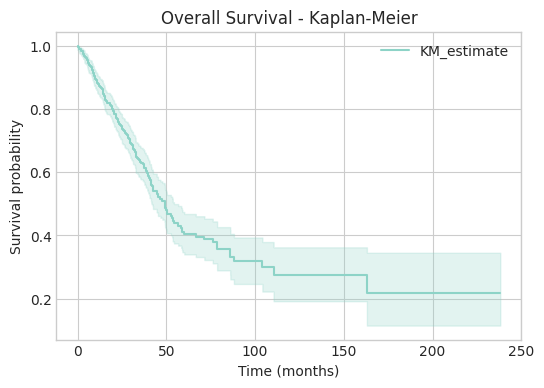

In [4]:
# Kaplan-Meier curve for the whole cohort
kmf = fit_km(data, "duration", "event")
ax = kmf.plot_survival_function(figsize=(6, 4))
ax.set_title("Overall Survival - Kaplan-Meier")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival probability")
plt.show()

Rows used for Cox model: 567
Cox C-index: 0.537


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
ARHGEF10L,-0.166941,0.846249,0.089454,-0.342269,0.008386,0.710157,1.008421,0.0,-1.866219,0.062011,4.011338


,HR,CI_lower,CI_upper,p_value
covariate,,,,
ARHGEF10L,0.846249,0.710157,1.008421,0.062011


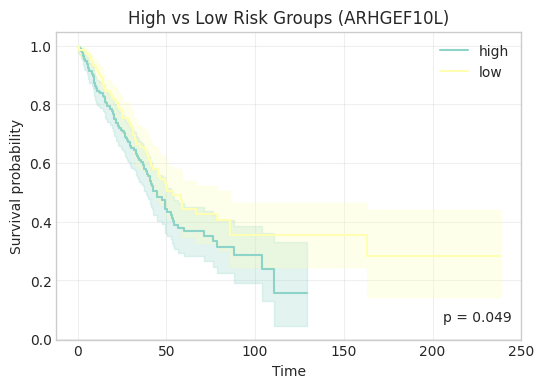

In [5]:
# Build a simple univariate Cox model with one representative gene

demo_gene = next(
    gene for gene in expr_df.columns
    if gene != "PATIENT_ID"
)

cox_df = data[
    ["duration", "event", demo_gene]
].copy()

cox_df[demo_gene] = pd.to_numeric(
    cox_df[demo_gene],
    errors="coerce",
)

cox_df = cox_df.dropna(
    subset=[demo_gene]
)

print(
    f"Rows used for Cox model: {len(cox_df)}"
)

cox_model = CoxModel(
    penalizer=0.01
)

cox_model.fit(
    cox_df,
    "duration",
    "event",
)

print(
    f"Cox C-index: {cox_model.score(cox_df):.3f}"
)

display(
    cox_model.summary
)

display(
    cox_model.hazard_ratios
)

risk_scores = (
    cox_model.predict_risk_score(
        cox_df
    )
)

cox_df["risk_group"] = (
    split_risk_group(
        risk_scores
    )
)

ax = plot_grouped_km_with_pvalue(
    cox_df,
    duration_col="duration",
    event_col="event",
    group_col="risk_group",
    group_a="low",
    group_b="high",
)

ax.set_title(
    f"High vs Low Risk Groups ({demo_gene})"
)

plt.show()

Rows used for LASSO-Cox model: 567
Features used: 200


/home/vincent/Desktop/SurvivalNet/src/survivalnet/models/lasso_cox.py:94: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  numeric_features[col] = values
/home/vincent/Desktop/SurvivalNet/src/survivalnet/models/lasso_cox.py:94: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  numeric_features[col] = values
/home/vincent/Desktop/SurvivalNet/src/survivalnet/models/lasso_cox.py:94: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider jo

Best penalizer: 0.05
Selected features: 14
Selected features:
['BRDT', 'BPIL1', 'EPS8L3', 'SPRR1B', 'KLK12', 'GLB1L3', 'INSL4', 'LOC149620', 'IGF2BP1', 'C1QL2', 'ANXA10', 'UPK1B', 'C4orf7', 'SULT4A1']
LASSO C-index: 0.676


,HR,CI_lower,CI_upper,p_value
covariate,,,,
BRDT,0.983777,0.877338,1.103129,0.779513
BPIL1,0.997225,0.879494,1.130715,0.965415
EPS8L3,1.008032,0.848731,1.197232,0.927371
SPRR1B,1.120700,0.991479,1.266762,0.068294
KLK12,0.928111,0.806429,1.068154,0.298132
GLB1L3,0.952883,0.829244,1.094957,0.496103
INSL4,1.010707,0.872625,1.170639,0.887005
LOC149620,0.937982,0.816019,1.078173,0.367649
IGF2BP1,1.063987,0.916459,1.235263,0.415399


/tmp/ipykernel_5840/3876178711.py:194: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lasso_df["risk_group"] = (


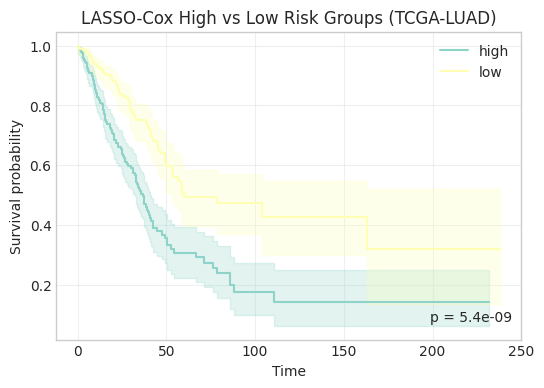

In [6]:
gene_cols = [
    col
    for col in expr_df.columns
    if col != "PATIENT_ID"
]

expr_lasso = expr_df.copy()

expr_lasso[gene_cols] = np.log2(
    expr_lasso[gene_cols] + 1
)

expression_rate = (
    expr_lasso[gene_cols] > 0
).mean(axis=0)

kept_genes = (
    expression_rate[
        expression_rate >= 0.1
    ]
    .index
    .tolist()
)

top_genes = (
    expr_lasso[kept_genes]
    .var(numeric_only=True)
    .sort_values(
        ascending=False
    )
    .head(200)
    .index
    .tolist()
)

lasso_df = (
    data.set_index("PATIENT_ID")
    [["duration", "event"]]
    .join(
        expr_lasso.set_index(
            "PATIENT_ID"
        )[top_genes],
        how="inner",
    )
    .reset_index()
)

for gene in top_genes:

    lasso_df[gene] = pd.to_numeric(
        lasso_df[gene],
        errors="coerce",
    )

    lasso_df[gene] = (
        lasso_df[gene]
        .fillna(
            lasso_df[gene].median()
        )
    )

print(
    f"Rows used for LASSO-Cox model: {len(lasso_df)}"
)

print(
    f"Features used: {len(top_genes)}"
)

sex_chromosome_genes = [
    "EIF1AY",
    "HY",
    "UTY",
    "USP9Y",
    "TTTY15",
    "CYorf15B",
    "DDX3Y",
    "RPS4Y1",
]

penalizer_grid = [
    0.1,
    0.05,
    0.02,
    0.01,
]

lasso_model = None

selected_features = []

for penalizer in penalizer_grid:

    try:

        candidate_model = (
            LassoCoxModel(
                penalizer=penalizer,
                cv=5,
                random_state=42,
            )
            .fit(
                lasso_df,
                "duration",
                "event",
            )
        )

        candidate_features = [
            gene
            for gene in candidate_model.selected_features
            if gene not in sex_chromosome_genes
        ]

        if (
            8
            <= len(candidate_features)
            <= 25
        ):

            lasso_model = candidate_model

            selected_features = (
                candidate_features
            )

            print(
                f"Best penalizer: {penalizer}"
            )

            print(
                f"Selected features: {len(selected_features)}"
            )

            break

    except Exception as exc:

        print(
            f"penalizer={penalizer} failed: {exc}"
        )

if lasso_model is None:

    fallback_penalizer = 0.005

    print(
        f"Falling back to penalizer={fallback_penalizer}"
    )

    lasso_model = (
        LassoCoxModel(
            penalizer=fallback_penalizer,
            cv=5,
            random_state=42,
        )
        .fit(
            lasso_df,
            "duration",
            "event",
        )
    )

    selected_features = [
        gene
        for gene in lasso_model.selected_features
        if gene not in sex_chromosome_genes
    ]

print(
    "Selected features:"
)

print(
    selected_features
)

print(
    f"LASSO C-index: {lasso_model.score(lasso_df):.3f}"
)

display(
    lasso_model.hazard_ratios.loc[
        selected_features
    ]
)

risk_scores = (
    lasso_model.predict_risk_score(
        lasso_df
    )
)

lasso_df["risk_group"] = (
    split_risk_group(
        risk_scores
    )
)

ax = plot_grouped_km_with_pvalue(
    lasso_df,
    duration_col="duration",
    event_col="event",
    group_col="risk_group",
    group_a="low",
    group_b="high",
)

ax.set_title(
    "LASSO-Cox High vs Low Risk Groups (TCGA-LUAD)"
)

plt.show()

DeepSurv samples: 567
DeepSurv features: 200


/home/vincent/Desktop/SurvivalNet/src/survivalnet/models/deepsurv.py:104: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  numeric_features[col] = values
/home/vincent/Desktop/SurvivalNet/src/survivalnet/models/deepsurv.py:104: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  numeric_features[col] = values
/home/vincent/Desktop/SurvivalNet/src/survivalnet/models/deepsurv.py:104: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider jo

DeepSurv training completed
DeepSurv C-index: 0.769


/home/vincent/miniconda3/envs/survivalnet/lib/python3.11/site-packages/torchtuples/base.py:669: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.net.load_state_dict(torch.

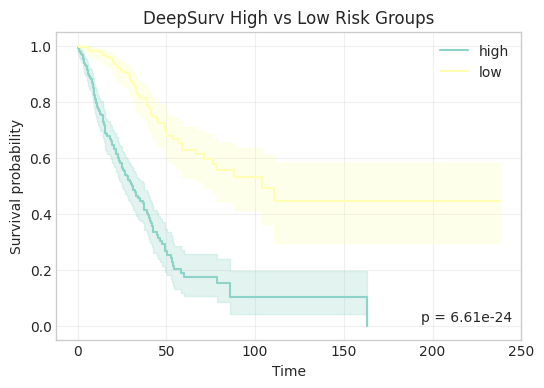

In [7]:
# =========================
# DeepSurv neural network model
# =========================

from survivalnet import DeepSurvModel

feature_cols = top_genes

deep_df = (
    data.set_index("PATIENT_ID")[["duration", "event"]]
    .join(
        expr_df.set_index("PATIENT_ID")[feature_cols],
        how="inner",
    )
    .reset_index(drop=True)
)

for gene in feature_cols:

    deep_df[gene] = pd.to_numeric(
        deep_df[gene],
        errors="coerce",
    )

deep_df = deep_df.fillna(0)

print(
    f"DeepSurv samples: {len(deep_df)}"
)

print(
    f"DeepSurv features: {len(feature_cols)}"
)

deep_model = DeepSurvModel(
    hidden_dim1=128,
    hidden_dim2=64,
    dropout=0.3,
    learning_rate=1e-3,
    epochs=100,
    batch_size=64,
    random_state=42,
)

deep_model.fit(
    deep_df,
    duration_col="duration",
    event_col="event",
)

print(
    "DeepSurv training completed"
)

print(
    f"DeepSurv C-index: {deep_model.score(deep_df):.3f}"
)

risk_scores = deep_model.predict_risk_score(
    deep_df
)

deep_df["risk_group"] = split_risk_group(
    risk_scores
)

ax = plot_grouped_km_with_pvalue(
    deep_df,
    duration_col="duration",
    event_col="event",
    group_col="risk_group",
    group_a="low",
    group_b="high",
)

ax.set_title(
    "DeepSurv High vs Low Risk Groups"
)

plt.show()

In [8]:
print("=" * 40)
print("Model Comparison")
print("=" * 40)

print(
    f"CoxModel      C-index: {cox_model.score(cox_df):.3f}"
)

print(
    f"LassoCoxModel C-index: {lasso_model.score(lasso_df):.3f}"
)

print(
    f"DeepSurvModel C-index: {deep_model.score(deep_df):.3f}"
)

Model Comparison
CoxModel      C-index: 0.537
LassoCoxModel C-index: 0.676
DeepSurvModel C-index: 0.769
